In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Semana12_Clasificacion_AutoTec_Jocelyn") \
    .getOrCreate()

ruta_datos = "/home/jovyan/work/autotec/Jocelyn/datos_etiquetados_kmeans"

df_clusters = spark.read.parquet(ruta_datos)

print("Datos cargados:", df_clusters.count())
df_clusters.show(5, truncate=False)
df_clusters.printSchema()

Datos cargados: 1904
+----------+---------+--------+---------+---------------+-----------------------------------+----------------------------------------------------------------------------------+----------+
|precio_num|km_num   |year_num|marca_cat|combustible_cat|features                           |scaledFeatures                                                                    |prediction|
+----------+---------+--------+---------+---------------+-----------------------------------+----------------------------------------------------------------------------------+----------+
|22997.0   |272940.0 |2024.0  |16.0     |0.0            |[22997.0,272940.0,2024.0,16.0,0.0] |[6.326974969337196E-4,0.5357132765125391,576.0991962974324,1.1977563611077962,0.0]|1         |
|22997.0   |117660.0 |2024.0  |16.0     |0.0            |[22997.0,117660.0,2024.0,16.0,0.0] |[6.326974969337196E-4,0.2309372906663199,576.0991962974324,1.1977563611077962,0.0]|1         |
|23997.0   |10770.0  |2025.0  |16.0    

In [2]:
df_supervisado = df_clusters.withColumnRenamed("prediction", "label")

train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

print("Registros entrenamiento:", train_data.count())
print("Registros prueba:", test_data.count())

Registros entrenamiento: 1382
Registros prueba: 522


In [3]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

dt = DecisionTreeClassifier(
    featuresCol="scaledFeatures",
    labelCol="label",
    maxDepth=5,
    seed=42
)

dt_model = dt.fit(train_data)

predicciones_dt = dt_model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy_dt = evaluator.evaluate(predicciones_dt)

print(f"Accuracy Árbol de Decisión: {accuracy_dt * 100:.2f}%")

Accuracy Árbol de Decisión: 95.98%


In [4]:
print("=== ESTRUCTURA DEL ÁRBOL DE DECISIÓN ===")
print(dt_model.toDebugString)

=== ESTRUCTURA DEL ÁRBOL DE DECISIÓN ===
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_2f1bab07c8cc, depth=5, numNodes=49, numClasses=3, numFeatures=5
  If (feature 4 <= 1.0477057169731796)
   If (feature 2 <= 574.533709350972)
    If (feature 1 <= 1.7478298260951715)
     If (feature 0 <= 1.3425941579495375)
      If (feature 2 <= 573.6798073801754)
       Predict: 2.0
      Else (feature 2 > 573.6798073801754)
       Predict: 1.0
     Else (feature 0 > 1.3425941579495375)
      Predict: 2.0
    Else (feature 1 > 1.7478298260951715)
     If (feature 1 <= 1.8411586393807697)
      If (feature 0 <= 4.0297083261243603E-4)
       Predict: 1.0
      Else (feature 0 > 4.0297083261243603E-4)
       Predict: 2.0
     Else (feature 1 > 1.8411586393807697)
      Predict: 2.0
   Else (feature 2 > 574.533709350972)
    If (feature 0 <= 1.3425941579495375)
     If (feature 1 <= 2.5305356970106487)
      Predict: 1.0
     Else (feature 1 > 2.5305356970106487)
      If (feature 0 <= 6.

In [5]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="scaledFeatures",
    labelCol="label",
    numTrees=30,
    maxDepth=5,
    seed=42
)

rf_model = rf.fit(train_data)

predicciones_rf = rf_model.transform(test_data)

accuracy_rf = evaluator.evaluate(predicciones_rf)

print(f"Accuracy Random Forest: {accuracy_rf * 100:.2f}%")

Accuracy Random Forest: 95.79%


In [6]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="scaledFeatures",
    labelCol="label",
    maxIter=20
)

lr_model = lr.fit(train_data)

predicciones_lr = lr_model.transform(test_data)

accuracy_lr = evaluator.evaluate(predicciones_lr)

print(f"Accuracy Regresión Logística: {accuracy_lr * 100:.2f}%")

Accuracy Regresión Logística: 99.43%


In [7]:
print("=========================================")
print("RESULTADOS CLASIFICACIÓN SUPERVISADA")
print("=========================================")
print(f"Árbol de Decisión:      {accuracy_dt * 100:.2f}%")
print(f"Random Forest:          {accuracy_rf * 100:.2f}%")
print(f"Regresión Logística:    {accuracy_lr * 100:.2f}%")
print("=========================================")

print("""
Interpretación:
En esta etapa se utilizaron los clusters creados en Semana 10 como etiquetas para entrenar modelos supervisados.
El objetivo fue evaluar si los modelos son capaces de aprender los patrones creados por K-Means a partir de variables como precio, kilometraje, año, marca y combustible.
Un mayor accuracy indica que el modelo logra replicar mejor la segmentación generada previamente.
""")

RESULTADOS CLASIFICACIÓN SUPERVISADA
Árbol de Decisión:      95.98%
Random Forest:          95.79%
Regresión Logística:    99.43%

Interpretación:
En esta etapa se utilizaron los clusters creados en Semana 10 como etiquetas para entrenar modelos supervisados.
El objetivo fue evaluar si los modelos son capaces de aprender los patrones creados por K-Means a partir de variables como precio, kilometraje, año, marca y combustible.
Un mayor accuracy indica que el modelo logra replicar mejor la segmentación generada previamente.



In [8]:
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier

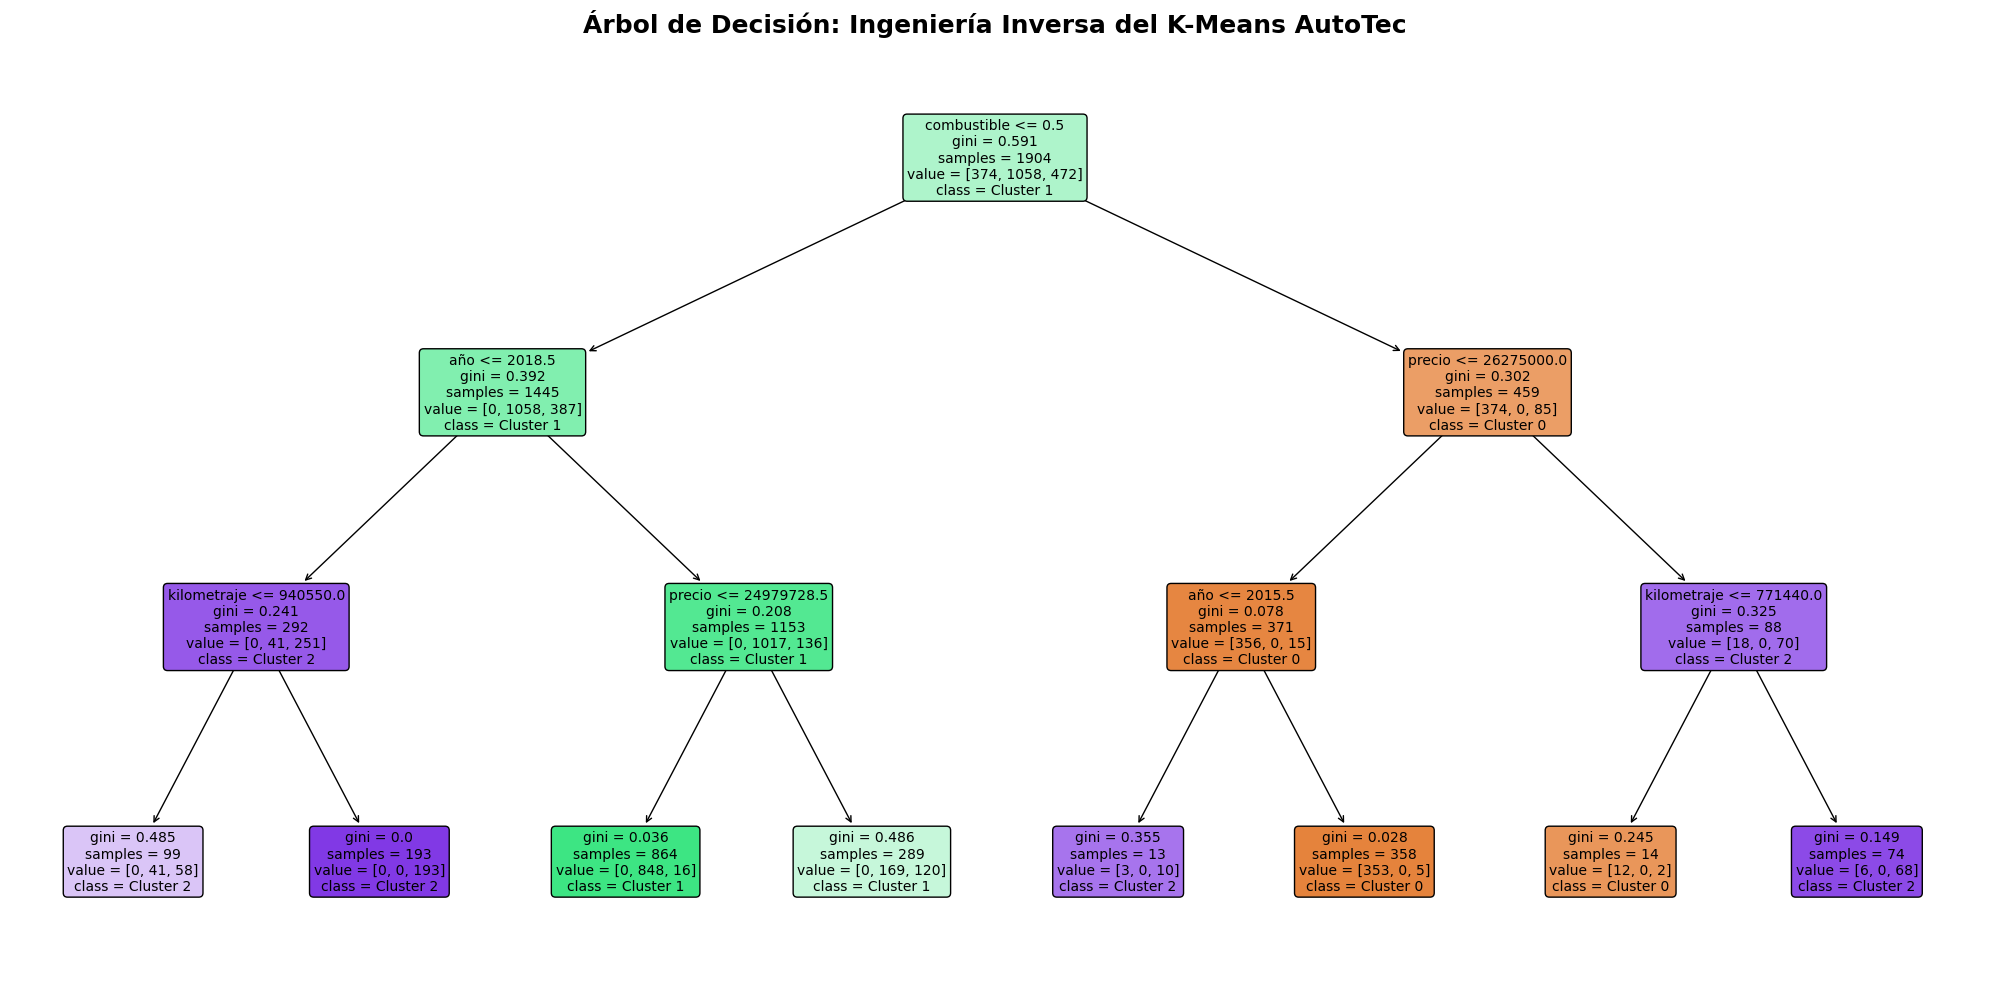

In [9]:
# Convertimos Spark a Pandas

df_pandas = df_supervisado.select(
    "precio_num",
    "km_num",
    "year_num",
    "marca_cat",
    "combustible_cat",
    "label"
).toPandas()

# Variables predictoras

X_muestra = df_pandas[
    [
        "precio_num",
        "km_num",
        "year_num",
        "marca_cat",
        "combustible_cat"
    ]
]

# Variable objetivo

y_muestra = df_pandas["label"]

# Modelo Árbol de Decisión Scikit-Learn

sk_dt = SklearnClassifier(
    max_depth=3,
    random_state=42
)

sk_dt.fit(X_muestra, y_muestra)

# Etiquetas

nombres_features = [
    "precio",
    "kilometraje",
    "año",
    "marca",
    "combustible"
]

nombres_clases = [
    f"Cluster {int(c)}"
    for c in sorted(y_muestra.unique())
]

# Gráfico

plt.figure(figsize=(20,10), dpi=100)

plot_tree(
    sk_dt,
    feature_names=nombres_features,
    class_names=nombres_clases,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title(
    "Árbol de Decisión: Ingeniería Inversa del K-Means AutoTec",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [10]:
print("""
Interpretación:

El árbol de decisión permite visualizar qué variables son más importantes para diferenciar los clusters generados por K-Means.

En el caso de AutoTec, variables como precio, kilometraje y año del vehículo son las que más contribuyen a la segmentación de los automóviles.

Esta representación facilita comprender cómo los algoritmos de aprendizaje supervisado pueden reproducir los patrones detectados previamente por el modelo no supervisado.
""")


Interpretación:

El árbol de decisión permite visualizar qué variables son más importantes para diferenciar los clusters generados por K-Means.

En el caso de AutoTec, variables como precio, kilometraje y año del vehículo son las que más contribuyen a la segmentación de los automóviles.

Esta representación facilita comprender cómo los algoritmos de aprendizaje supervisado pueden reproducir los patrones detectados previamente por el modelo no supervisado.

